This notebook outlines a pipeline for **multi-class classification** of mycetoma species. It uses **domain-independent features**, which are extracted by a pre-trained deep learning model via **Img2Vec**. The histopathology images are first pre-processed with **Macenko stain normalization** before being fed into the model.
The core of this approach is to use a deep learning model to create a feature vector for each image, which serves as a richer representation than traditional hand-crafted features. This feature vector is then used to train a classical machine learning model, specifically a **Logistic Regression** classifier with diverse solver, for the final classification task. The notebook evaluates the model's performance by generating a classification report and a confusion matrix.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# standard library
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
%matplotlib inline
import os
import pprint
from collections import Counter
import joblib
from pprint import pprint
import cv2

# skimage libraries
from skimage.io import imread
from skimage.transform import resize
#from skimage.feature import hog
from skimage.transform import rescale

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [ ]:
!pip install --quiet img2vec_pytorch
from img2vec_pytorch import Img2Vec
from PIL import Image


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.3 MB/s eta 0:00:00


In [ ]:
#function to load dataset and extract features
#To explore the relations between meme and non-meme images, we vectorize the images using Img2Vec.
#Img2Vec is a pre-trained pytorch model that proves to perform well for image classification
def load_dataset_and_extract_features(data_dir):
  img2vec = Img2Vec()
  features =[]
  labels = []
  for category in os.listdir(data_dir):
    for img_path in os.listdir(os.path.join(data_dir,category)):
      img_path_ = os.path.join(data_dir,category, img_path)
      img = cv2.imread(img_path_)
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)#CONVERT bgr TO rgb
      img = cv2.resize(img, (224,224)) #resize image to a standard size
      img = Image.fromarray(img) #convert Numpy array to PIL Image
      img_features = img2vec.get_vec(img)
      features.append(img_features)
      labels.append(category)
  return features, labels

In [ ]:
train_dir = "/content/drive/MyDrive/MACENKO SET/train/"
val_dir= "/content/drive/MyDrive/MACENKO SET/test/"

In [ ]:
train_features, train_labels = load_dataset_and_extract_features(train_dir)
val_features, val_labels = load_dataset_and_extract_features(val_dir)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 308MB/s]


In [ ]:
# Define class mapping
class_mapping = {
    "actionmadureapelletrii": "AP",
    "falciformisporasenegalensis": "FS",
    "madurellamycetomatis": "MM",
    "streptomycessomaliesnis": "SS"
}

In [ ]:
# Convert labels to short names
train_labels = [class_mapping[label] for label in train_labels]
val_labels = [class_mapping[label] for label in val_labels]

In [ ]:
#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
##LogisticRegressionCV multinomial multiclass solver (‘lbfgs’, ‘newton-cg’, ‘sag’, ‘saga’, saga l2)

In [ ]:
# "lbfgs" solver Logistic regression model and evaluation
from sklearn.linear_model import LogisticRegression
dt_model= LogisticRegression(solver='lbfgs', random_state=0)
dt_model.fit(train_features,train_labels)
y_pred_dt=dt_model.predict(val_features)

In [ ]:
print("Logistic regression Model performance:")
print("Accuracy:", accuracy_score(val_labels,y_pred_dt),'\n')
print("Classification Report:")
print(classification_report(val_labels,y_pred_dt))

Logistic regression Model performance:
Accuracy: 0.9323308270676691 

Classification Report:
              precision    recall  f1-score   support

          AP       0.87      0.94      0.91        72
          FS       0.89      0.84      0.86        37
          MM       0.97      0.99      0.98       114
          SS       0.97      0.84      0.90        43

    accuracy                           0.93       266
   macro avg       0.93      0.90      0.91       266
weighted avg       0.93      0.93      0.93       266



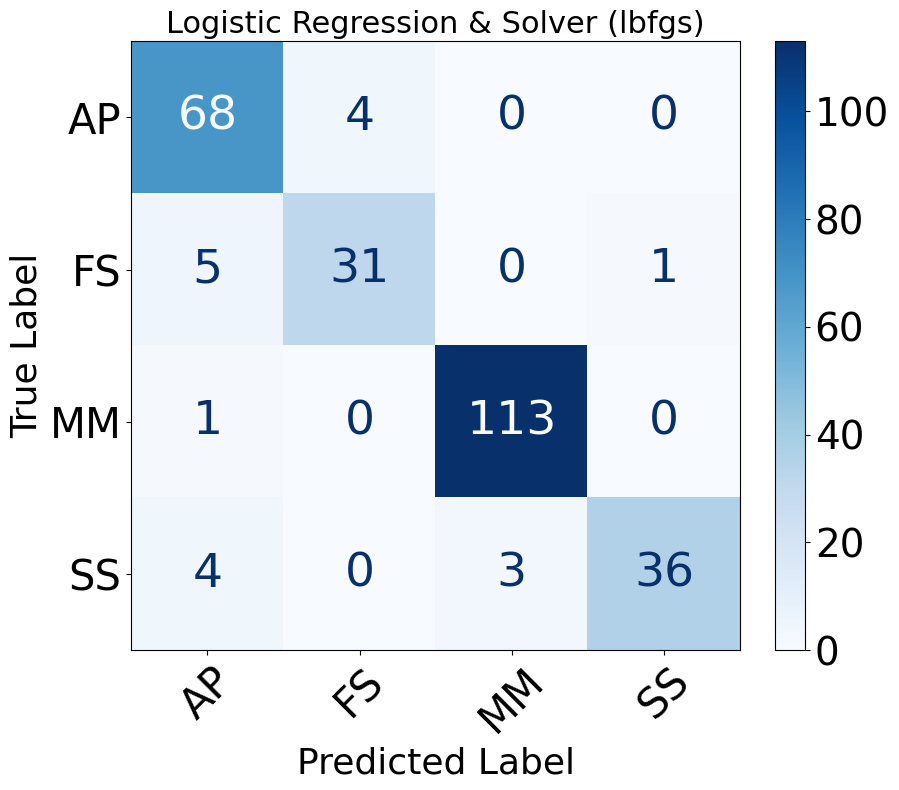

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(val_labels, y_pred_dt, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("Logistic Regression & Solver (lbfgs)", fontsize=22)
plt.xlabel("Predicted Label", fontsize=26)
plt.ylabel("True Label", fontsize=26)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
#LogisticRegressionCV multinomial multiclass solver (‘lbfgs’, ‘newton-cg’, ‘sag’, ‘saga’)

In [ ]:
#Logistic regressionCV model and evaluation
from sklearn.linear_model import LogisticRegressionCV
CV_model= LogisticRegressionCV(solver='lbfgs', random_state=0, cv=5)
CV_model.fit(train_features,train_labels)
y_pred_cv=CV_model.predict(val_features)

In [ ]:
print("Logistic regression CV Model performance:")
print("Accuracy:", accuracy_score(val_labels,y_pred_cv),'\n')
print("Classification Report:")
print(classification_report(val_labels,y_pred_cv))

Logistic regression CV Model performance:
Accuracy: 0.924812030075188 

Classification Report:
              precision    recall  f1-score   support

          AP       0.85      0.94      0.89        72
          FS       0.89      0.84      0.86        37
          MM       0.97      0.99      0.98       114
          SS       0.97      0.79      0.87        43

    accuracy                           0.92       266
   macro avg       0.92      0.89      0.90       266
weighted avg       0.93      0.92      0.92       266



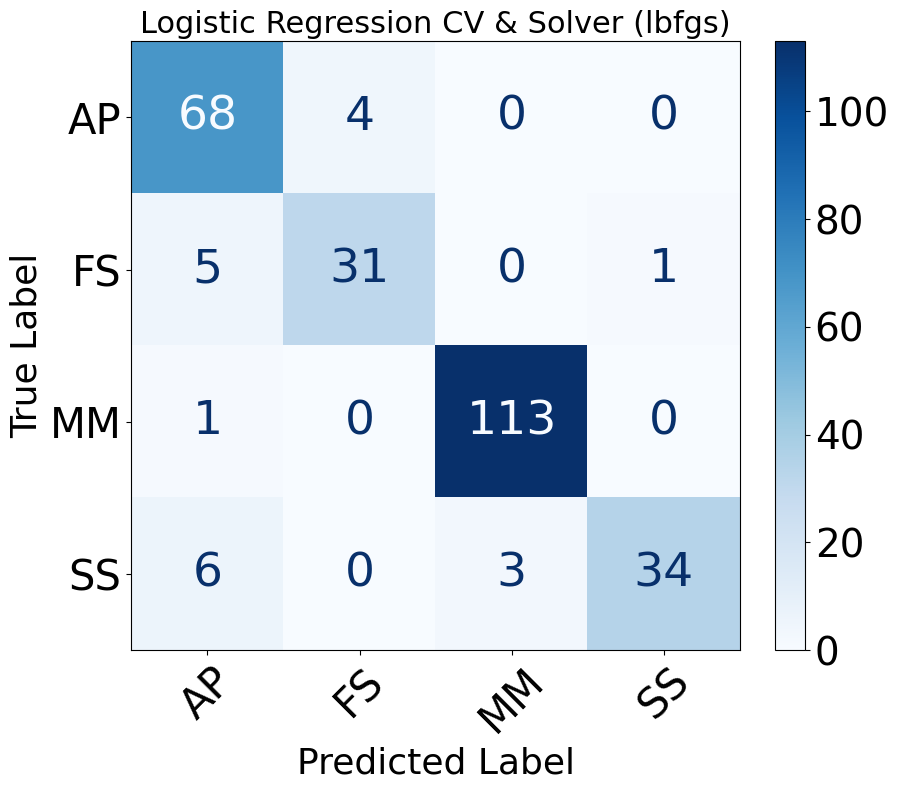

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt_CV = confusion_matrix(val_labels, y_pred_cv, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_CV,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("Logistic Regression CV & Solver (lbfgs)", fontsize=22)
plt.xlabel("Predicted Label", fontsize=26)
plt.ylabel("True Label", fontsize=26)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


In [ ]:
# "newton-cg" solver Logistic regression model and evaluation
from sklearn.linear_model import LogisticRegression
newton_cg_model= LogisticRegression(solver='newton-cg', random_state=0)
newton_cg_model.fit(train_features,train_labels)
y_pred_newton_cg=newton_cg_model.predict(val_features)

In [ ]:
print("Logistic regression CV Model performance:")
print("Accuracy:", accuracy_score(val_labels,y_pred_newton_cg),'\n')
print("Classification Report:")
print(classification_report(val_labels,y_pred_newton_cg))

Logistic regression CV Model performance:
Accuracy: 0.9360902255639098 

Classification Report:
              precision    recall  f1-score   support

          AP       0.87      0.96      0.91        72
          FS       0.91      0.84      0.87        37
          MM       0.97      0.99      0.98       114
          SS       0.97      0.84      0.90        43

    accuracy                           0.94       266
   macro avg       0.93      0.91      0.92       266
weighted avg       0.94      0.94      0.94       266



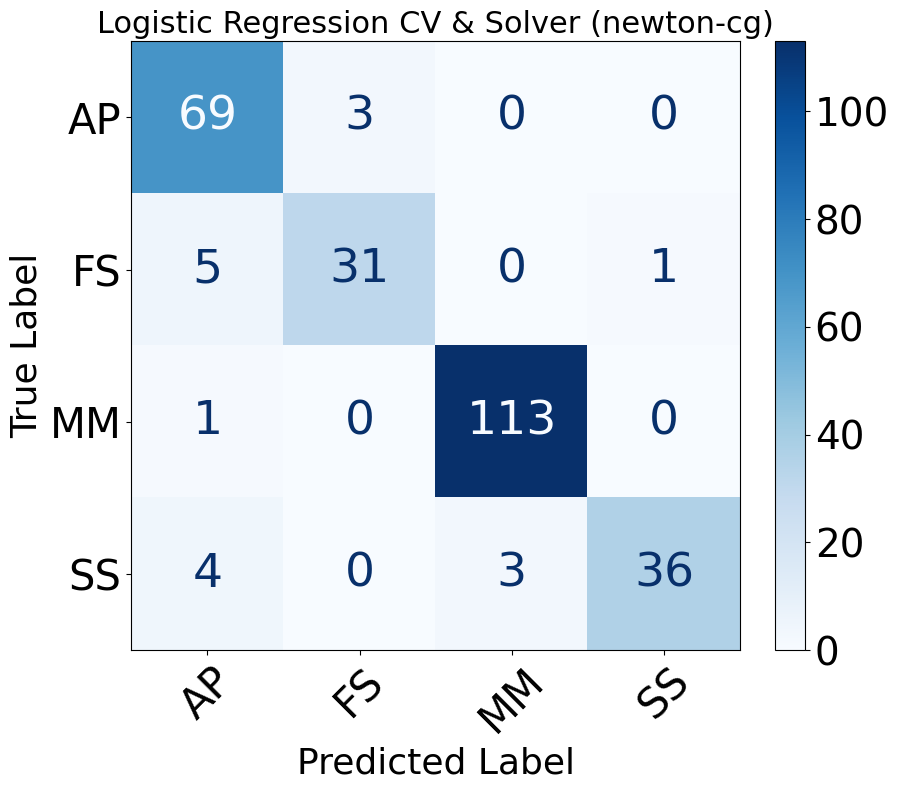

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt_newton_cg = confusion_matrix(val_labels, y_pred_newton_cg, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_newton_cg,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("Logistic Regression CV & Solver (newton-cg)", fontsize=22)
plt.xlabel("Predicted Label", fontsize=26)
plt.ylabel("True Label", fontsize=26)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



In [ ]:
# "sag" solver Logistic regression model and evaluation
from sklearn.linear_model import LogisticRegression
sag_model= LogisticRegression(solver='sag', random_state=0)
sag_model.fit(train_features,train_labels)
y_pred_sag=sag_model.predict(val_features)

In [ ]:
print("Logistic regression CV Model performance:")
print("Accuracy:", accuracy_score(val_labels,y_pred_sag),'\n')
print("Classification Report:")
print(classification_report(val_labels,y_pred_sag))

Logistic regression CV Model performance:
Accuracy: 0.9285714285714286 

Classification Report:
              precision    recall  f1-score   support

          AP       0.86      0.94      0.90        72
          FS       0.89      0.84      0.86        37
          MM       0.97      0.99      0.98       114
          SS       0.97      0.81      0.89        43

    accuracy                           0.93       266
   macro avg       0.92      0.90      0.91       266
weighted avg       0.93      0.93      0.93       266



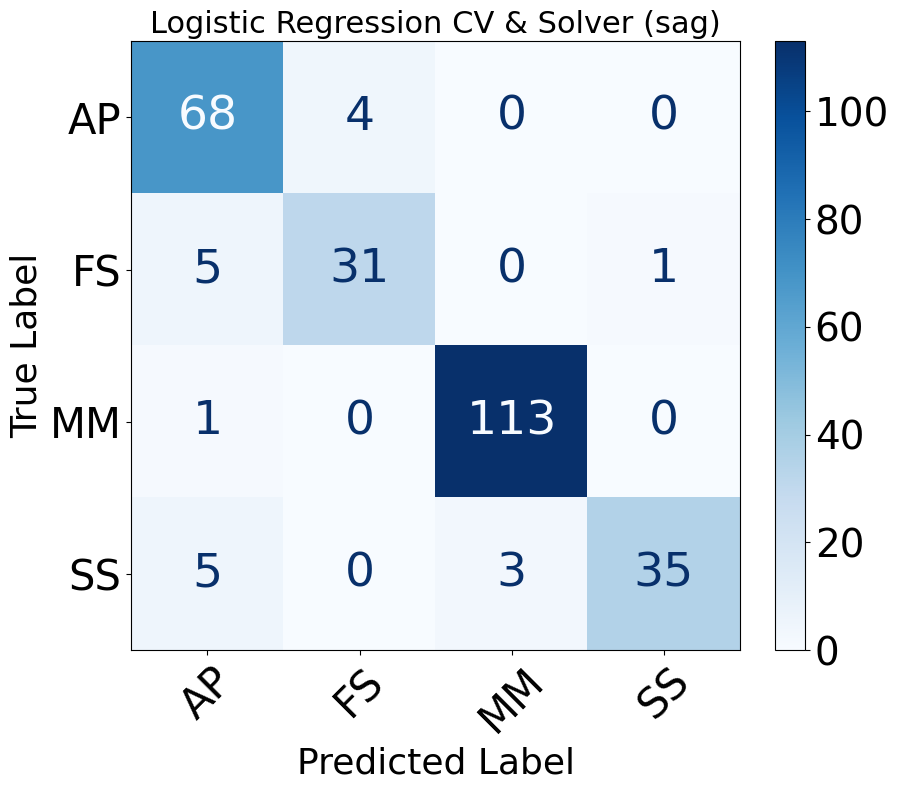

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt_sag = confusion_matrix(val_labels, y_pred_sag, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_sag,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("Logistic Regression CV & Solver (sag)", fontsize=22)
plt.xlabel("Predicted Label", fontsize=26)
plt.ylabel("True Label", fontsize=26)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()



In [ ]:
# "saga" solver Logistic regression model and evaluation
from sklearn.linear_model import LogisticRegression
saga_model= LogisticRegression(solver='saga', random_state=0)
saga_model.fit(train_features,train_labels)
y_pred_saga=saga_model.predict(val_features)

In [ ]:
print("Logistic regression CV Model performance:")
print("Accuracy:", accuracy_score(val_labels,y_pred_saga),'\n')
print("Classification Report:")
print(classification_report(val_labels,y_pred_saga))

Logistic regression CV Model performance:
Accuracy: 0.9285714285714286 

Classification Report:
              precision    recall  f1-score   support

          AP       0.86      0.94      0.90        72
          FS       0.89      0.84      0.86        37
          MM       0.97      0.99      0.98       114
          SS       0.97      0.81      0.89        43

    accuracy                           0.93       266
   macro avg       0.92      0.90      0.91       266
weighted avg       0.93      0.93      0.93       266



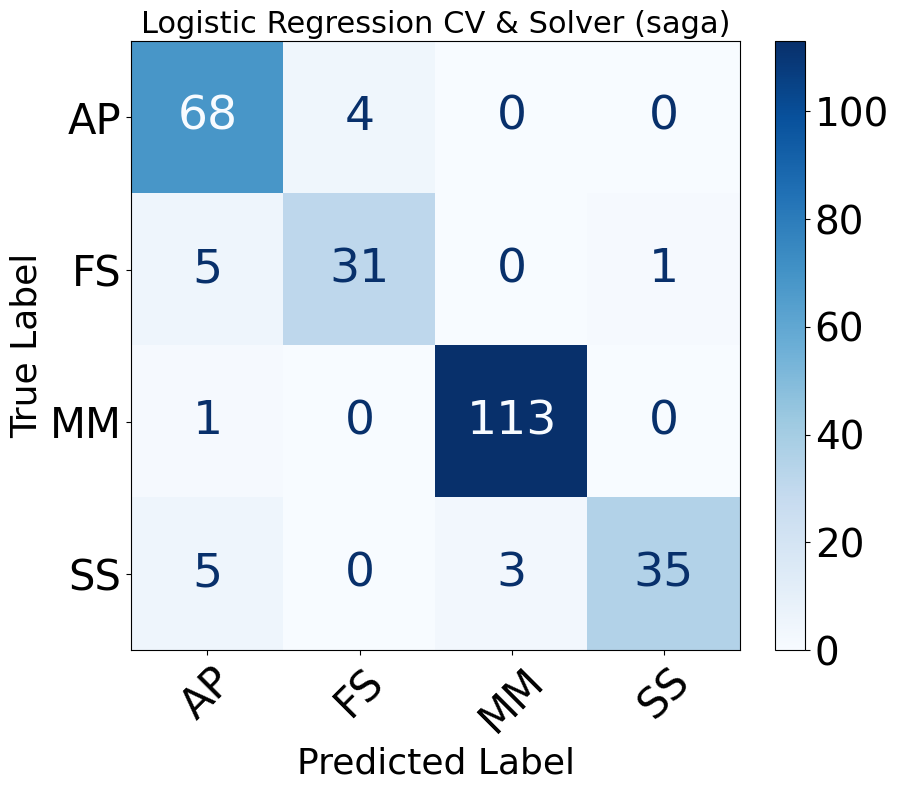

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt_saga = confusion_matrix(val_labels, y_pred_saga, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_saga,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("Logistic Regression CV & Solver (saga)", fontsize=22)
plt.xlabel("Predicted Label", fontsize=26)
plt.ylabel("True Label", fontsize=26)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()




In [ ]:
# "saga" solver Logistic regression model and evaluation
from sklearn.linear_model import LogisticRegression
liblinear_model= LogisticRegression(solver='liblinear', random_state=0)
liblinear_model.fit(train_features,train_labels)
y_pred_liblinear=liblinear_model.predict(val_features)

In [ ]:
print("Logistic regression CV Model performance:")
print("Accuracy:", accuracy_score(val_labels,y_pred_liblinear),'\n')
print("Classification Report:")
print(classification_report(val_labels,y_pred_liblinear))

Logistic regression CV Model performance:
Accuracy: 0.924812030075188 

Classification Report:
              precision    recall  f1-score   support

          AP       0.86      0.93      0.89        72
          FS       0.86      0.81      0.83        37
          MM       0.97      0.99      0.98       114
          SS       0.97      0.84      0.90        43

    accuracy                           0.92       266
   macro avg       0.92      0.89      0.90       266
weighted avg       0.93      0.92      0.92       266



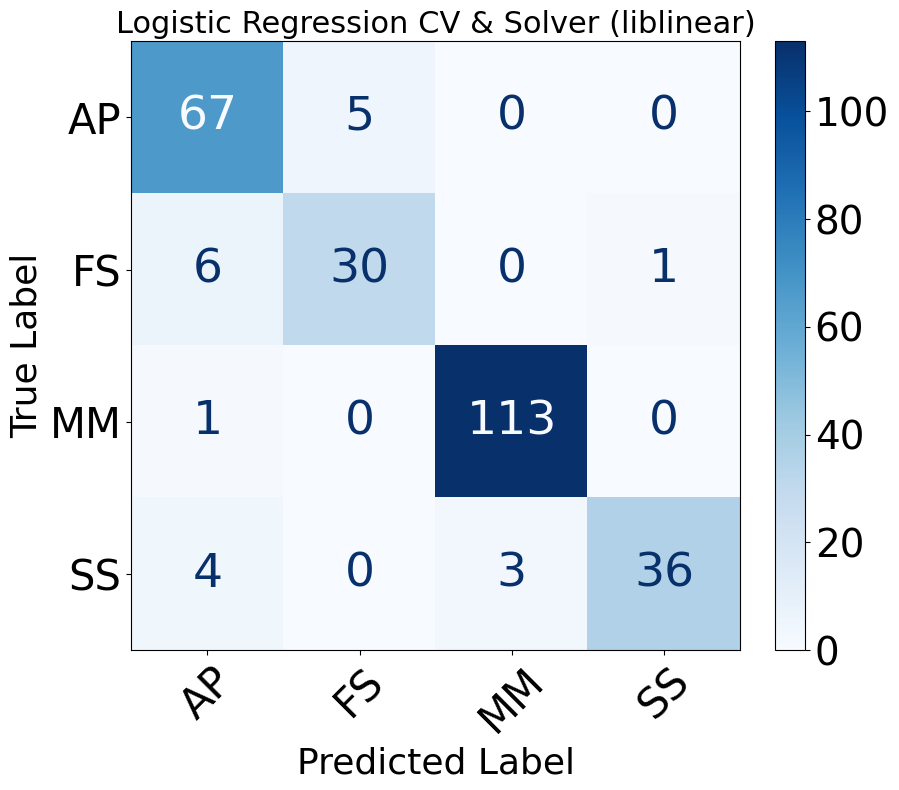

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt_liblinear = confusion_matrix(val_labels, y_pred_liblinear, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_liblinear,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("Logistic Regression CV & Solver (liblinear)", fontsize=22)
plt.xlabel("Predicted Label", fontsize=26)
plt.ylabel("True Label", fontsize=26)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()




In [ ]:
# "saga" solver Logistic regression model and evaluation
from sklearn.linear_model import LogisticRegression
saga_model2= LogisticRegression(fit_intercept=True, multi_class='auto',penalty='l2', solver='saga',max_iter=10000, C=50)
saga_model2.fit(train_features,train_labels)
y_pred_saga2=saga_model2.predict(val_features)

In [ ]:
print("Logistic regression CV Model performance:")
print("Accuracy:", accuracy_score(val_labels,y_pred_saga2),'\n')
print("Classification Report:")
print(classification_report(val_labels,y_pred_saga2))

Logistic regression CV Model performance:
Accuracy: 0.9285714285714286 

Classification Report:
              precision    recall  f1-score   support

          AP       0.86      0.94      0.90        72
          FS       0.89      0.84      0.86        37
          MM       0.97      0.99      0.98       114
          SS       0.97      0.81      0.89        43

    accuracy                           0.93       266
   macro avg       0.92      0.90      0.91       266
weighted avg       0.93      0.93      0.93       266



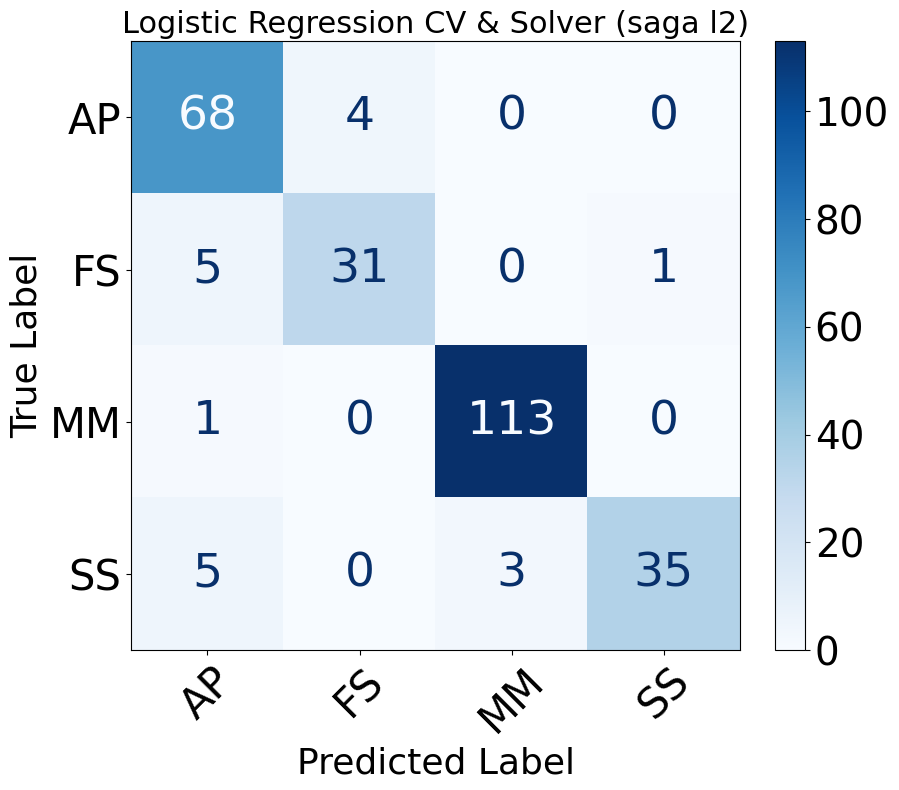

In [ ]:
# Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt_saga2 = confusion_matrix(val_labels, y_pred_saga2, labels=["AP", "FS", "MM", "SS"])

# Display the confusion matrix with correct class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_saga2,
    display_labels=["AP", "FS", "MM", "SS"]
)

# Create figure with adjusted layout
fig, ax = plt.subplots(figsize=(10, 8))  # Slightly wider figure to accommodate colorbar
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45, colorbar=False)  # Plot without default colorbar

# Add colorbar manually with proper sizing
im = disp.im_
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
cbar.ax.tick_params(labelsize=28)  # Set colorbar tick label size

# Customize font sizes for matrix values
for texts in disp.text_.ravel():
    texts.set_fontsize(34)  # Adjust the font size for matrix values

# Customize font sizes for other elements
plt.title("Logistic Regression CV & Solver (saga l2)", fontsize=22)
plt.xlabel("Predicted Label", fontsize=26)
plt.ylabel("True Label", fontsize=26)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()




